temperature
inside mean  19.534007188813028
outside mean  15.670832622111345
inside std  0.1950088120527288
outside std  1.7532119565097513
Are they different?  True
-------------------
gas
inside mean  184763.32773109243
outside mean  167870.1806722689
inside std  14444.720757651978
outside std  21729.788448624608
Are they different?  True
-------------------
humidity
inside mean  33.568937655100875
outside mean  37.16197291629853
inside std  0.37247716170776635
outside std  2.062995906445026
Are they different?  True
-------------------
pressure
inside mean  1003.2545129139211
outside mean  1003.3078593155382
inside std  0.02020708289200334
outside std  0.2788223550392218
Are they different?  True
-------------------
altitude
inside mean  83.55361419659569
outside mean  83.10616094196526
inside std  0.1695939967399444
outside std  2.340369799935372
Are they different?  True
-------------------
pm10standard
inside mean  0.0
outside mean  0.9789915966386554
inside std  0.0
outside std 

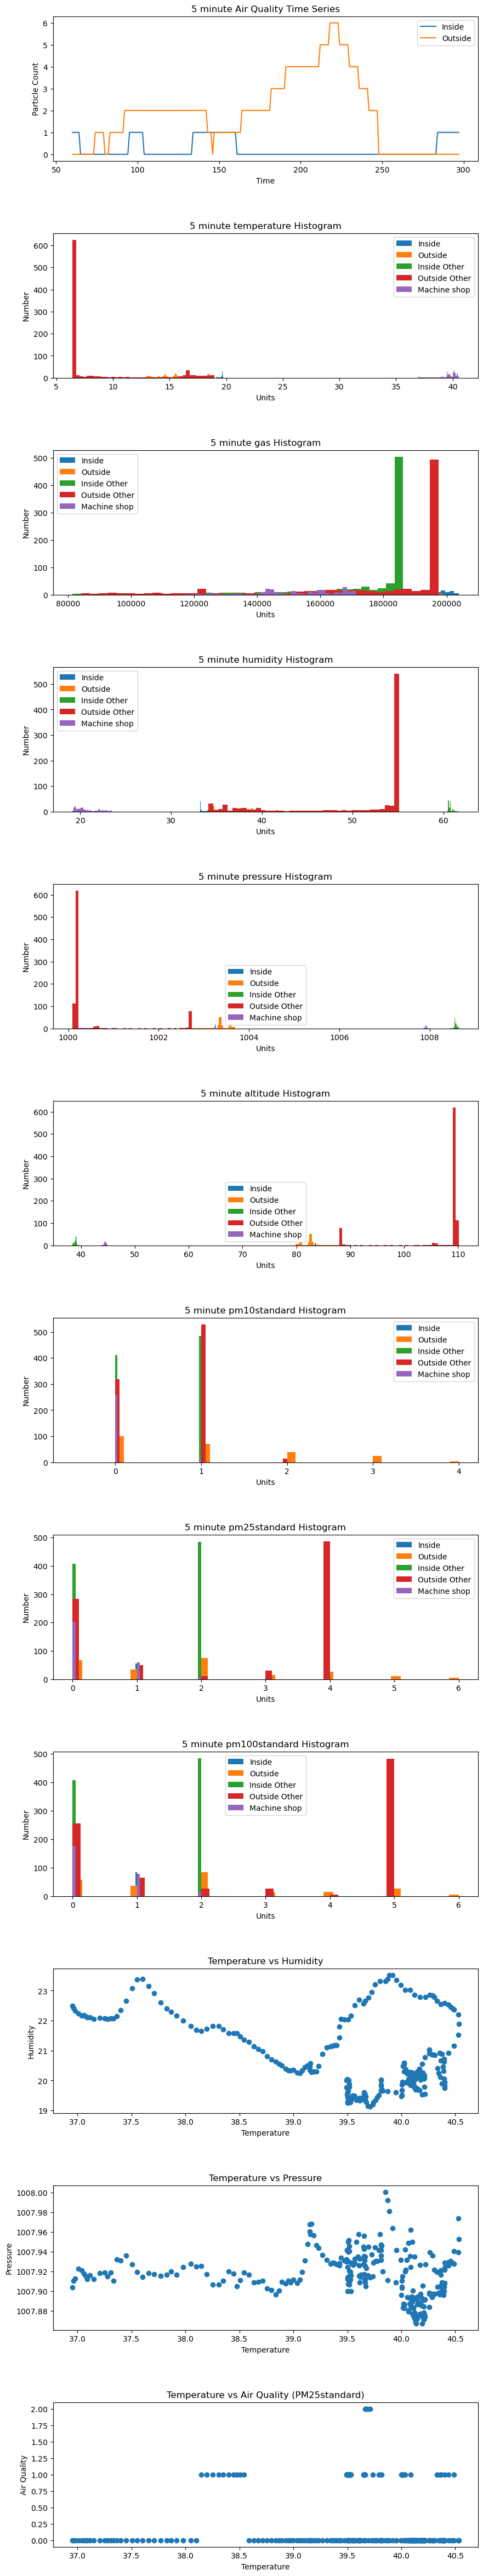

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

drop_columns = [
    'pm10env',
    'pm25env',
    'pm100 env',
    'p03um',
    'p05um',
    'p10um',
    'p25um',
    'p50um',
    'p100um'
]

# Prepare inside data
data_inside = pd.read_csv('data/inside_5min.csv')
data_inside = data_inside.drop(columns=drop_columns)
data_inside = data_inside.iloc[60:]

# Prepare outside data
data_outside = pd.read_csv('data/double_data_outside_5min.csv')
data_outside = data_outside.drop(columns=drop_columns)
data_outside = data_outside.iloc[60:]

# combine
data = pd.concat([data_inside,data_outside])

# Other group data
# Prepare inside data
data_inside_other = pd.read_csv('data/other_group/testindoor.csv')
data_inside_other = data_inside_other.iloc[60:]

# Prepare outside data
data_outside_other = pd.read_csv('data/other_group/testoutdoor.csv')
data_outside_other = data_outside_other.iloc[60:]

# Machine shop data
data_shop = pd.read_csv('data/machine_shop_data.csv')
data_shop = data_shop.drop(columns=drop_columns)
data_shop = data_shop.iloc[60:]

columns = [
  'temperature',
  'gas',
  'humidity',
  'pressure',
  'altitude',
  'pm10standard',
  'pm25standard',
  'pm100standard'
]

# Inside vs Outside data
for column in columns:
  mean_inside = np.mean(data_inside[column])
  std_inside = np.std(data_inside[column])
  mean_outside = np.mean(data_outside[column])
  std_outside = np.std(data_outside[column])
  std_mean = std_outside / np.sqrt(300)
  isDifferent = np.abs(mean_inside - mean_outside) > (2 * std_mean)
  print(column)
  print('inside mean ', mean_inside)
  print('outside mean ', mean_outside)
  print('inside std ', std_inside)
  print('outside std ', std_outside)
  print('Are they different? ',isDifferent)
  print('-------------------')

# Comparison with other Group inside
for column in columns:
  mean_ours = np.mean(data_inside[column])
  std_ours = np.std(data_inside[column])
  mean_other = np.mean(data_inside_other[column])
  std_other = np.std(data_inside_other[column])
  std_mean = std_other / np.sqrt(300)
  isDifferent = np.abs(mean_ours - mean_other) > (2 * std_mean)
  print(column)
  # print('our mean ', mean_ours)
  # print('other mean ', mean_other)
  # print('our std ', std_ours)
  # print('other std ', std_other)
  # print('Are they different? ',isDifferent)
  # print('-------------------')

# Comparison with other Group outside
for column in columns:
  mean_ours = np.mean(data_outside[column])
  std_ours = np.std(data_outside[column])
  mean_other = np.mean(data_outside_other[column])
  std_other = np.std(data_outside_other[column])
  std_mean = std_other / np.sqrt(300)
  isDifferent = np.abs(mean_ours - mean_other) > (2 * std_mean)
  # print(column)
  # print('our mean ', mean_ours)
  # print('other mean ', mean_other)
  # print('our std ', std_ours)
  # print('other std ', std_other)
  # print('Are they different? ',isDifferent)
  # print('-------------------')

# Machine shop data vs Outside data
for column in columns:
  mean_shop = np.mean(data_shop[column])
  std_shop = np.std(data_shop[column])
  mean_outside = np.mean(data_outside[column])
  std_outside = np.std(data_outside[column])
  std_mean = std_outside / np.sqrt(300)
  isDifferent = np.abs(mean_shop - mean_outside) > (2 * std_mean)
  # print(column)
  # print('inside mean ', mean_inside)
  # print('outside mean ', mean_outside)
  # print('inside std ', std_inside)
  # print('outside std ', std_outside)
  # print('Are they different? ',isDifferent)
  # print('-------------------')

# times = []
# for entry in data_outside['time']:
#     dt = datetime.strptime(entry, '%a %b %d %H:%M:%S %Y')
#     times.append(dt)

fig, ax = plt.subplots(figsize=(10,60),nrows=12)
plt.subplots_adjust(hspace=0.5)
ax[0].plot(data_inside['pm25standard'], label='Inside')
ax[0].plot(data_outside['pm25standard'], label='Outside')

ax[0].legend() 
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Particle Count')
ax[0].set_title('5 minute Air Quality Time Series')

# histograms
for i, column in enumerate(columns):
    ax[i+1].hist(data_inside[column],bins=40, label='Inside')
    ax[i+1].hist(data_outside[column],bins=40, label='Outside')
    ax[i+1].hist(data_inside_other[column],bins=40, label='Inside Other')
    ax[i+1].hist(data_outside_other[column],bins=40, label='Outside Other')
    ax[i+1].hist(data_shop[column],bins=40, label='Machine shop')
    ax[i+1].legend() 
    ax[i+1].set_xlabel('Units')
    ax[i+1].set_ylabel('Number')
    ax[i+1].set_title('5 minute ' + column + ' Histogram')

ax[9].scatter(data_shop['temperature'], data_shop['humidity'])
ax[9].set_xlabel('Temperature')
ax[9].set_ylabel('Humidity')
ax[9].set_title('Temperature vs Humidity')

ax[10].scatter(data_shop['temperature'], data_shop['pressure'])
ax[10].set_xlabel('Temperature')
ax[10].set_ylabel('Pressure')
ax[10].set_title('Temperature vs Pressure')

ax[11].scatter(data_shop['temperature'], data_shop['pm25standard'])
ax[11].set_xlabel('Temperature')
ax[11].set_ylabel('Air Quality')
ax[11].set_title('Temperature vs Air Quality (PM25standard)')

plt.show()

### Lab Activity Questions

Step 1
3.c - no, our distribution is not well defined by a gaussian, and we need to take a LOT more data (more than 5 minute's worth and/or more than 1 data point every second)

Step 2
2 - the sensors are reading somewhat different data, with the air sensor being mostly accurate, but the weather sensor being very different. This indicates that the precision is fine, but the accuracy is subpar (and the sensors need to be calibrated)

Step 4
1. The plot shows that humidity is negatively correlated to temperatures below 39C. We can perform a best-fit with the truncated data. 
2. The plot shows that pressure doesn't change when temperature is below 39C. This can either mean that random changes in the weather occurr above 39C, or that our sensor changes at 39C.
3. Our plot shows that there is no correlation between air quality and temperature.
